Загрузка датасета Luna288/image-captioning-FACAD-base с HuggingFace

In [ ]:
!pip install datasets

In [1]:
from datasets import load_dataset
import pandas as pd
from tqdm import tqdm
import os
import shutil
from PIL import Image

print("Загрузка датасета через Hugging Face datasets...")
dataset = load_dataset("Luna288/image-captioning-FACAD-base")

# Сразу берем только первые 6000
num_samples = 6000
dataset_subset = dataset['train'].select(range(num_samples))

# Создаем папки
sample_dir = 'facad_dataset_6k'
if os.path.exists(sample_dir):
    shutil.rmtree(sample_dir)

os.makedirs(f"{sample_dir}/images", exist_ok=True)
os.makedirs(f"{sample_dir}/metadata", exist_ok=True)

# Сохраняем изображения и описания
print(f"Сохраняем первые {num_samples} изображений...")
data = []

for i, item in enumerate(tqdm(dataset_subset)):
    image = item['image']
    caption = item['text']

    img_filename = f"image_{i}.jpg"
    img_path = f"{sample_dir}/images/{img_filename}"
    image.save(img_path)

    data.append({
        'image_filename': img_filename,
        'caption': caption
    })

# Сохраняем метаданные
df = pd.DataFrame(data)
df.to_csv(f"{sample_dir}/metadata/metadata.csv", index=False)

print(f"\nГотово! Создана подвыборка из {len(df)} изображений")

Загрузка датасета через Hugging Face datasets...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Сохраняем первые 6000 изображений...


100%|██████████| 6000/6000 [00:06<00:00, 934.12it/s]



Готово! Создана подвыборка из 6000 изображений


In [2]:
df

,image_filename,caption
0,image_0.jpg,flower fall and spot spatter this wear everywh...
1,image_1.jpg,inspired by classic american style this prepst...
2,image_2.jpg,pretty floral lace bloom across this cropped c...
3,image_3.jpg,if the sweater is clean so is the crisp white ...
4,image_4.jpg,frilly trim enhances the whimsical appeal of t...
...,...,...
5995,image_5995.jpg,essential black pants crafted of a wrinkle res...
5996,image_5996.jpg,a feline pattern put an exotic spin on a woven...
5997,image_5997.jpg,look refined while you stay relaxed in these j...
5998,image_5998.jpg,lightweight french terry and a cozy cut make t...


In [3]:
files = os.listdir('facad_dataset_6k/images')
count = len(files)
print(f"Всего изображений: {count}")

Всего изображений: 6000


Импортирование библиотек

In [4]:
import numpy as np
import pandas as pd
import os
from PIL import Image
from keras.models import Model
from keras.layers import Input, LSTM, Dense, Embedding, Concatenate, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.applications.inception_v3 import InceptionV3
from keras.applications.inception_v3 import preprocess_input
from keras.preprocessing import image
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


# Пути к вашим данным
images_path = 'facad_dataset/images/'
csv_path = 'facad_dataset/metadata/metadata.csv'

Предобработка изображений

In [5]:
# Загрузка предобученной модели InceptionV3
base_model = InceptionV3(weights='imagenet')
model_features = Model(base_model.input, base_model.layers[-2].output)

def extract_features(img_path, model, target_size=(180, 180)):
    """
    Извлекает признаки из изображения
    InceptionV3 требует размер (299, 299), поэтому изменяем размер
    """
    try:
        # Загружаем и изменяем размер изображения
        img = image.load_img(img_path, target_size=(299, 299))  # InceptionV3 требует 299x299
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = preprocess_input(x)
        features = model.predict(x, verbose=0)
        return features.flatten()
    except Exception as e:
        print(f"Ошибка при обработке {img_path}: {e}")
        return None

# Извлекаем признаки для всех изображений
print("Извлечение признаков изображений...")
image_ids = []
image_features = []
captions = []

for idx, row in df.iterrows():
    img_filename = row['image_filename']
    caption = row['caption']

    img_path = os.path.join(images_path, img_filename)

    if os.path.exists(img_path):
        features = extract_features(img_path, model_features)
        if features is not None:
            image_ids.append(img_filename)
            image_features.append(features)
            captions.append(caption)

    # Прогресс каждые 100 изображений
    if (idx + 1) % 100 == 0:
        print(f"Обработано {idx + 1}/{len(df)} изображений")

# Конвертируем в numpy массивы
image_features = np.array(image_features)
print(f"Форма матрицы признаков: {image_features.shape}")
print(f"Всего обработано изображений: {len(image_ids)}")

Извлечение признаков изображений...
Обработано 100/6000 изображений
Обработано 200/6000 изображений
Обработано 300/6000 изображений
Обработано 400/6000 изображений
Обработано 500/6000 изображений
Обработано 600/6000 изображений
Обработано 700/6000 изображений
Обработано 800/6000 изображений
Обработано 900/6000 изображений
Обработано 1000/6000 изображений
Обработано 1100/6000 изображений
Обработано 1200/6000 изображений
Обработано 1300/6000 изображений
Обработано 1400/6000 изображений
Обработано 1500/6000 изображений
Обработано 1600/6000 изображений
Обработано 1700/6000 изображений
Обработано 1800/6000 изображений
Обработано 1900/6000 изображений
Обработано 2000/6000 изображений
Обработано 2100/6000 изображений
Обработано 2200/6000 изображений
Обработано 2300/6000 изображений
Обработано 2400/6000 изображений
Обработано 2500/6000 изображений
Обработано 2600/6000 изображений
Обработано 2700/6000 изображений
Обработано 2800/6000 изображений
Обработано 2900/6000 изображений
Обработано 3000/

In [6]:
# Используем данные из DataFrame
captions = df['caption'].tolist()  # берем колонку с описаниями
print(f"Пример описания: {captions[0]}")
print(f"Всего описаний: {len(captions)}")

# Добавляем стартовый и стоповый токены
captions = ['startseq ' + str(caption) + ' endseq' for caption in captions]
print(f"Пример с токенами: {captions[0]}")

# Токенизация
tokenizer = Tokenizer()
tokenizer.fit_on_texts(captions)
vocab_size = len(tokenizer.word_index) + 1
print(f"Размер словаря: {vocab_size}")

# Конвертируем текст в последовательности
sequences = tokenizer.texts_to_sequences(captions)

# Находим максимальную длину подписи
max_length = max(len(seq) for seq in sequences)
print(f"Максимальная длина подписи: {max_length}")

# Паддинг последовательностей
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post')

# Разделяем на входные данные для декодера и целевые данные
decoder_input_data = padded_sequences[:, :-1]  # все кроме последнего токена
decoder_target_data = padded_sequences[:, 1:]   # все кроме первого токена

# One-hot encoding для целевых данных
decoder_target_one_hot = np.zeros((len(captions), max_length-1, vocab_size), dtype='float32')
for i, seq in enumerate(decoder_target_data):
    for t, token in enumerate(seq):
        if token > 0:
            decoder_target_one_hot[i, t, token] = 1.0

print(f"Форма decoder_input: {decoder_input_data.shape}")
print(f"Форма decoder_target: {decoder_target_one_hot.shape}")

# Проверка соответствия
print(f"\nПроверка соответствия:")
print(f"Количество изображений: {len(image_features)}")
print(f"Количество описаний: {len(captions)}")
print(f"Должны совпадать: {len(image_features) == len(captions)}")

Пример описания: flower fall and spot spatter this wear everywhere top cut with a gracefully pleated neckline
Всего описаний: 6000
Пример с токенами: startseq flower fall and spot spatter this wear everywhere top cut with a gracefully pleated neckline endseq
Размер словаря: 6507
Максимальная длина подписи: 82
Форма decoder_input: (6000, 81)
Форма decoder_target: (6000, 81, 6507)

Проверка соответствия:
Количество изображений: 6000
Количество описаний: 6000
Должны совпадать: True


In [7]:
X_img_train, X_img_val, X_text_train, X_text_val, y_train, y_val = train_test_split(
    image_features, decoder_input_data, decoder_target_data,
    test_size=0.2, random_state=42
)

print(f"\nTrain size: {len(X_img_train)}")
print(f"Validation size: {len(X_img_val)}")


Train size: 4800
Validation size: 1200


In [8]:
embedding_dim = 256
lstm_units = 256
dropout_rate = 0.3

# Вход для изображения
image_input = Input(shape=(2048,), name='image_input')
image_dense = Dense(embedding_dim, activation='relu', name='image_dense')(image_input)
image_dropout = Dropout(dropout_rate)(image_dense)

# Вход для текста
decoder_inputs = Input(shape=(max_length-1,), name='decoder_input')
decoder_embedding = Embedding(vocab_size, embedding_dim, name='decoder_embedding')(decoder_inputs)
decoder_dropout = Dropout(dropout_rate)(decoder_embedding)

# LSTM
decoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True, name='decoder_lstm')
decoder_outputs, _, _ = decoder_lstm(decoder_dropout, initial_state=[image_dropout, image_dropout])

# Выходной слой
decoder_dense = Dense(vocab_size, activation='softmax', name='decoder_output')
decoder_outputs = decoder_dense(decoder_outputs)

# Модель с sparse categorical crossentropy
model = Model([image_input, decoder_inputs], decoder_outputs)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Вместо categorical_crossentropy
    metrics=['accuracy']
)

print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ decoder_input       │ (None, 81)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 81, 256)   │  1,665,792 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_dense (Dense) │ (None, 256)       │    524,544 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 81, 256)   │          0 │ decoder_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ image_dense[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 81, 256), │    525,312 │ dropout_1[0][0],  │
│                     │ (None, 256),      │            │ dropout[0][0],    │
│                     │ (None, 256)]      │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 81, 6507)  │  1,672,299 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,387,947 (16.74 MB)

 Trainable params: 4,387,947 (16.74 MB)

 Non-trainable params: 0 (0.00 B)

None


In [10]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
checkpoint = ModelCheckpoint(
    'best_model_6k.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Обучение с уменьшенным batch_size для экономии памяти
history = model.fit(
    [X_img_train, X_text_train], y_train,
    validation_data=([X_img_val, X_text_val], y_val),
    batch_size=32,  # Уменьшили с 64 до 32
    epochs=20,
    callbacks=[checkpoint, early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7031 - loss: 3.5285
Epoch 1: val_loss improved from inf to 1.75849, saving model to best_model_6k.h5


150/150 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.7033 - loss: 3.5206 - val_accuracy: 0.7484 - val_loss: 1.7585 - learning_rate: 0.0010
Epoch 2/20
149/150 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7478 - loss: 1.7454
Epoch 2: val_loss improved from 1.75849 to 1.69668, saving model to best_model_6k.h5


150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.7478 - loss: 1.7451 - val_accuracy: 0.7555 - val_loss: 1.6967 - learning_rate: 0.0010
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7551 - loss: 1.6750
Epoch 3: val_loss improved from 1.69668 to 1.63964, saving model to best_model_6k.h5


150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.7551 - loss: 1.6749 - val_accuracy: 0.7595 - val_loss: 1.6396 - learning_rate: 0.0010
Epoch 4/20
149/150 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7611 - loss: 1.5981
Epoch 4: val_loss improved from 1.63964 to 1.58914, saving model to best_model_6k.h5


150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.7611 - loss: 1.5981 - val_accuracy: 0.7637 - val_loss: 1.5891 - learning_rate: 0.0010
Epoch 5/20
149/150 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7638 - loss: 1.5467
Epoch 5: val_loss improved from 1.58914 to 1.54896, saving model to best_model_6k.h5


...

150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.8097 - loss: 1.0350 - val_accuracy: 0.7969 - val_loss: 1.2840 - learning_rate: 0.0010
Epoch 17/20
149/150 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8140 - loss: 0.9990
Epoch 17: val_loss improved from 1.28400 to 1.27940, saving model to best_model_6k.h5


150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.8140 - loss: 0.9991 - val_accuracy: 0.7984 - val_loss: 1.2794 - learning_rate: 0.0010
Epoch 18/20
149/150 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8158 - loss: 0.9732
Epoch 18: val_loss improved from 1.27940 to 1.27537, saving model to best_model_6k.h5


150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.8158 - loss: 0.9733 - val_accuracy: 0.7987 - val_loss: 1.2754 - learning_rate: 0.0010
Epoch 19/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8190 - loss: 0.9459
Epoch 19: val_loss improved from 1.27537 to 1.27465, saving model to best_model_6k.h5


150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.8190 - loss: 0.9459 - val_accuracy: 0.7998 - val_loss: 1.2747 - learning_rate: 0.0010
Epoch 20/20
149/150 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8233 - loss: 0.9178
Epoch 20: val_loss improved from 1.27465 to 1.27310, saving model to best_model_6k.h5


150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.8233 - loss: 0.9179 - val_accuracy: 0.8000 - val_loss: 1.2731 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 20.


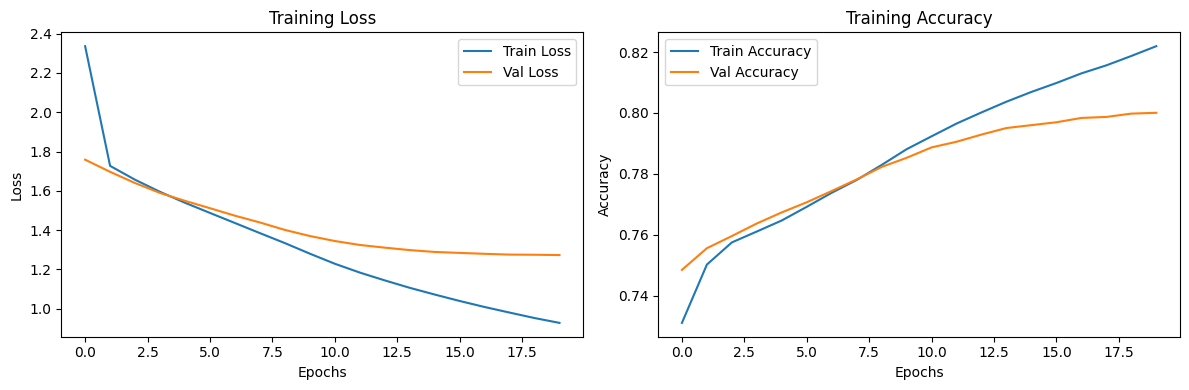

In [11]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy')

plt.tight_layout()
plt.savefig('training_history_6k.png')
plt.show()

In [12]:
def generate_caption(img_path, model, tokenizer, model_features, max_length):
    """Генерирует подпись для изображения"""
    # Извлекаем признаки
    features = extract_features(img_path, model_features)
    if features is None:
        return "Ошибка извлечения признаков"

    features = features.reshape(1, -1)

    # Начинаем с startseq
    in_text = 'startseq'

    for i in range(max_length-1):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length-1, padding='post')

        yhat = model.predict([features, sequence], verbose=0)
        yhat = np.argmax(yhat[0, i, :])

        # Конвертируем токен в слово
        word = ''
        for word, idx in tokenizer.word_index.items():
            if idx == yhat:
                break

        in_text += ' ' + word

        if word == 'endseq':
            break

    return in_text.replace('startseq', '').replace('endseq', '').strip()

# Тестируем на первом изображении
test_img_path = os.path.join(images_path, df['image_filename'].iloc[0])
generated = generate_caption(test_img_path, model, tokenizer, model_features, max_length)
print(f"\nОригинал: {df['caption'].iloc[0]}")
print(f"Сгенерировано: {generated}")

# Сохраняем модель и токенизатор
model.save('image_captioning_model_6k.h5')
import pickle
with open('tokenizer_6k.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("\nМодель обучена и сохранена!")


Оригинал: flower fall and spot spatter this wear everywhere top cut with a gracefully pleated neckline
Сгенерировано: a classic blouse with a flattering v neck and a flattering fit is a fresh update with a flattering surplice neckline and a flattering hem

Модель обучена и сохранена!


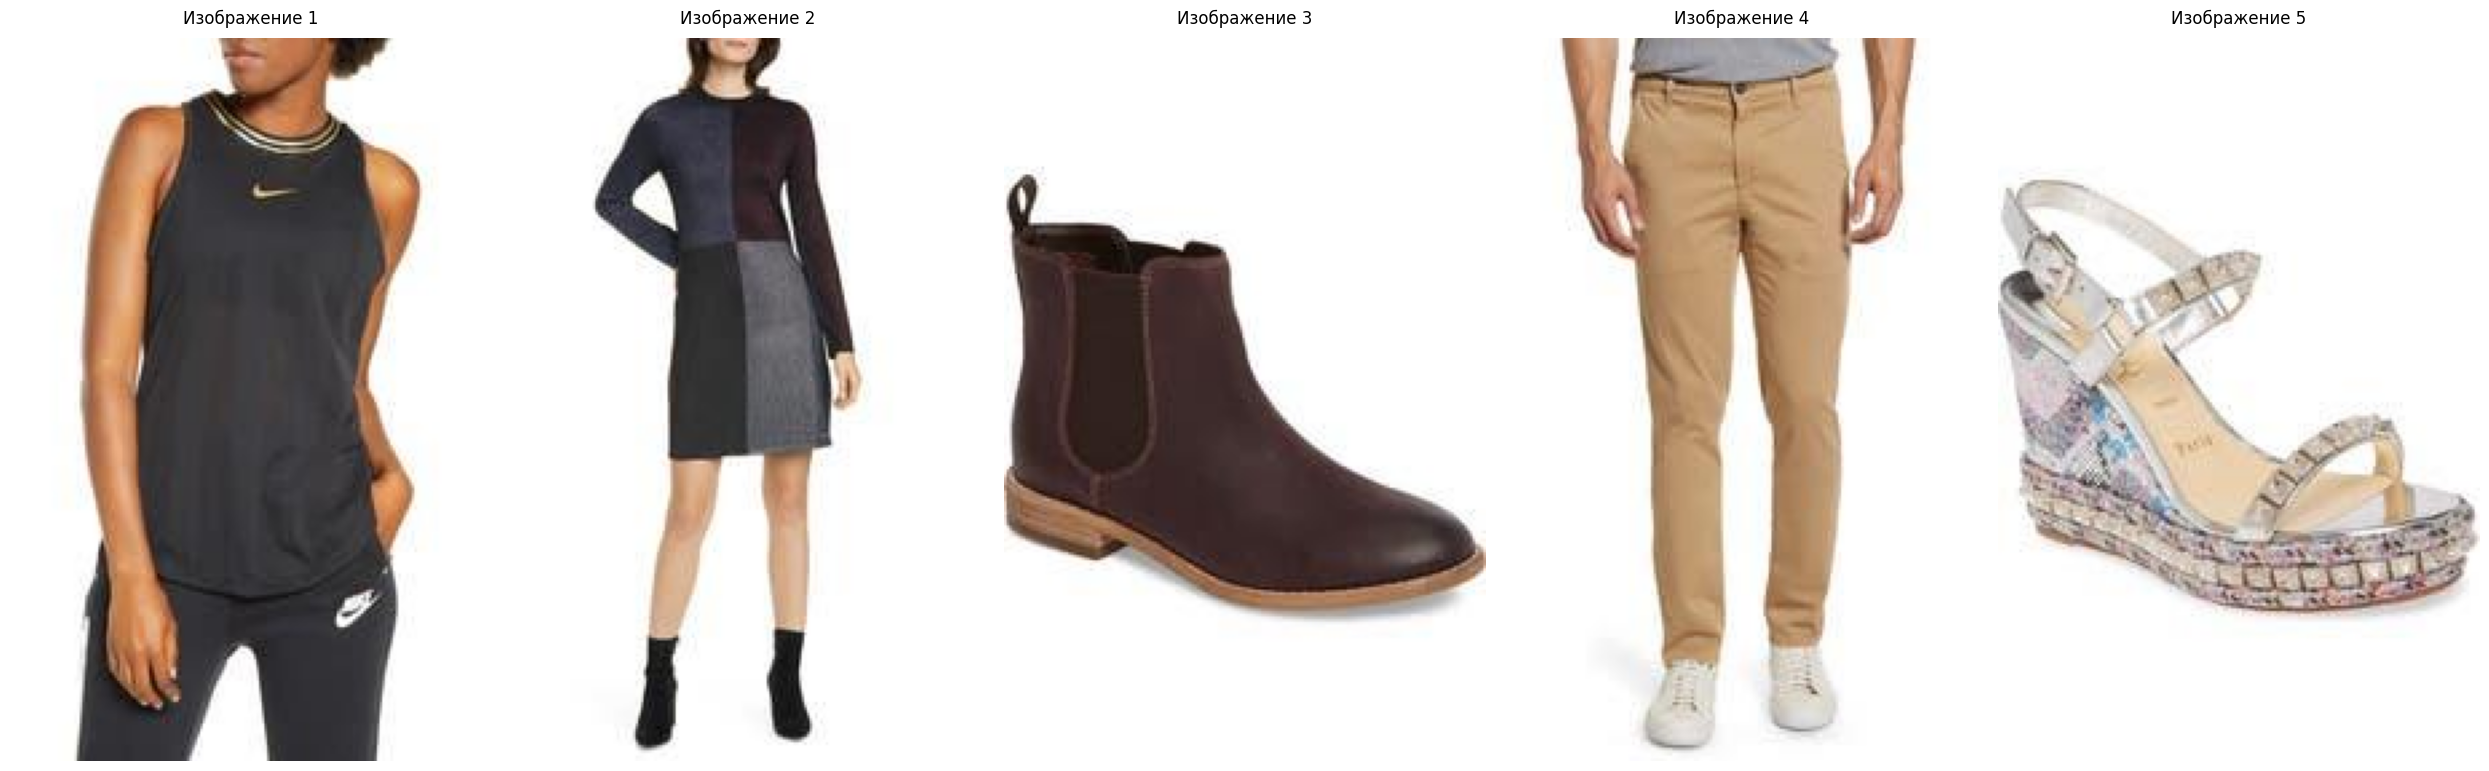


ОПИСАНИЯ ИЗОБРАЖЕНИЙ:

--- Изображение 1 ---
Файл: image_5238.jpg
Истинное описание: metallic accent and a signature nike swoosh shine on a breezy racerback tank with striped mesh inset
Сгенерированное описание: a soft cotton blend mean easy comfort in a versatile cotton blend sweater that s perfect for layering or on it own
--------------------------------------------------------------------------------

--- Изображение 2 ---
Файл: image_912.jpg
Истинное описание: a four color block pattern divide this sweater dress and conquers the season of sparkle with metallic shimmer knit into every segment
Сгенерированное описание: a wide leg jumpsuit with a flattering fit and a flattering fit is cut from a soft stretch blend and linen blend with a flattering high waist and a flattering hem
--------------------------------------------------------------------------------

--- Изображение 3 ---
Файл: image_204.jpg
Истинное описание: double needle topstitching add a rugged look to a simply styled 

In [15]:

import random

# Функция для генерации подписи (ваша существующая функция)
def generate_caption(img_path, model, tokenizer, model_features, max_length):
    """Генерирует подпись для изображения"""
    # Извлекаем признаки
    features = extract_features(img_path, model_features)
    if features is None:
        return "Ошибка извлечения признаков"

    features = features.reshape(1, -1)

    # Начинаем с startseq
    in_text = 'startseq'

    for i in range(max_length-1):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length-1, padding='post')

        yhat = model.predict([features, sequence], verbose=0)
        yhat = np.argmax(yhat[0, i, :])

        # Конвертируем токен в слово
        word = ''
        for word, idx in tokenizer.word_index.items():
            if idx == yhat:
                break

        in_text += ' ' + word

        if word == 'endseq':
            break

    return in_text.replace('startseq', '').replace('endseq', '').strip()

# Выбираем 5 случайных индексов
random.seed(42)  # для воспроизводимости результатов
indices = random.sample(range(len(df)), 5)

# Создаем фигуру для 5 изображений в ряд
fig, axes = plt.subplots(1, 5, figsize=(25, 8))

# Для каждого изображения
for i, (idx, ax) in enumerate(zip(indices, axes)):
    # Получаем данные
    img_filename = df.iloc[idx]['image_filename']
    true_caption = df.iloc[idx]['caption']
    img_path = os.path.join(images_path, img_filename)

    # Загружаем и отображаем изображение
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Изображение {i+1}", fontsize=12, pad=10)

plt.tight_layout()
plt.show()

# Выводим текстовые описания
print("\n" + "="*100)
print("ОПИСАНИЯ ИЗОБРАЖЕНИЙ:")
print("="*100)

for i, idx in enumerate(indices):
    # Получаем данные
    img_filename = df.iloc[idx]['image_filename']
    true_caption = df.iloc[idx]['caption']
    img_path = os.path.join(images_path, img_filename)

    # Генерируем описание
    generated = generate_caption(img_path, model, tokenizer, model_features, max_length)

    # Выводим информацию
    print(f"\n--- Изображение {i+1} ---")
    print(f"Файл: {img_filename}")
    print(f"Истинное описание: {true_caption}")
    print(f"Сгенерированное описание: {generated}")
    print("-" * 80)